In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
import json

from CMR_IA.fitting import make_boundary, get_wmse

cmr.analysis.setup_notebook()

SAVEFIG = False
SAVERES = False
SAVERES2 = True

## Load Stimuli and Semantic Matrix

In [182]:
# Load study and test data
df_study = pd.read_parquet("data/simu8_study.parquet")
df_test = pd.read_parquet("data/simu8_test.parquet")

In [183]:
# Inspect study data
df_study

,study_itemno1,study_itemno2,study_item1,study_item2,serial_pos,list,session,group
0,12,24,Face12,Joe,0,0,0,1
1,2,29,Face2,Mark,1,0,0,1
2,6,27,Face6,Dan,2,0,0,1
3,13,18,Face13,John,3,0,0,1
4,11,31,Face11,George,4,0,0,1
...,...,...,...,...,...,...,...,...
239995,12,18,Face12,John,11,0,9999,2
239996,7,29,Face7,Mark,12,0,9999,2
239997,10,26,Face10,Chris,13,0,9999,2
239998,1,23,Face1,Charles,14,0,9999,2


In [184]:
# Inspect test data
df_test

,test_itemno1,test_itemno2,test_item1,test_item2,correct_ans,study_pos,test,list,session,group
0,1,-1,Face1,None,30,6,1,0,0,1
1,2,-1,Face2,None,29,1,1,0,0,1
2,6,-1,Face6,None,27,2,1,0,0,1
3,14,-1,Face14,None,22,7,1,0,0,1
4,13,-1,Face13,None,18,3,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
399995,12,-1,Face12,None,18,11,2,0,9999,2
399996,3,-1,Face3,None,25,15,2,0,9999,2
399997,10,-1,Face10,None,26,13,2,0,9999,2
399998,16,-1,Face16,None,19,0,2,0,9999,2


In [185]:
# Load semantic matrix
sem_mat = np.load("data/simu8_smat.npy")

# Group 1

In [186]:
df_study_g1 = df_study.query("group == 1").copy()
df_test_g1 = df_test.query("group == 1").copy()
df_test_g1 = df_test_g1.rename(columns={"test_itemno1": "test_itemno", "test_item1": "test_item"})
df_test_g1.drop(columns=["test_itemno2", "test_item2"], inplace=True)

## Run CMR-IA

In [187]:
# Define parameters and load PSO results
params = cmr.load_params("8", fixed_params={"nitems_in_accumulator": 16, "ban_recall": np.arange(1, 17)})
params

{'beta_enc': 0.760942,
 'beta_rec': 0.824849,
 'beta_cue': 0.998476,
 'beta_rec_post': 0.0,
 'beta_distract': 0.849636,
 'beta_enc_inpair': None,
 's_fc': 0.27973,
 's_cf': 0.0,
 'phi_s': 7.422593,
 'phi_d': 0.4195,
 'psi_s': 0.0,
 'psi_c': 1.0,
 'd_assoc': None,
 'use_new_context': True,
 'use_flexible_thresh': True,
 'c_d': 0.0,
 'thresh_kernel_len': 10,
 'c_thresh_itm': 1.0,
 'c_thresh_assoc': 1.0,
 'c_s': 0.0,
 'thresh_sigma': 0.0,
 'recog_slope': 1.0,
 'kappa': 0.024833,
 'eta': 0.049837,
 'omega': 3.946671,
 'alpha': 0.676201,
 'lamb': 0.183632,
 'c_thresh': 0.18031,
 'ban_recall': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 16,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'gamma_fc': 0.497432,
 'gamma_cf': 0.73516}

In [188]:
# Run model or load saved results
if SAVERES:
    df_simu_g1, f_in, f_dif = cmr.run_norm_cr_multi_sess(params, df_study_g1, df_test_g1, sem_mat)
    df_simu_g1 = df_simu_g1.merge(df_test_g1, on=["session", "list", "test_itemno"])
    df_simu_g1.to_parquet("data/simu8_result_g1.parquet")
else:
    df_simu_g1 = pd.read_parquet("data/simu8_result_g1.parquet")
df_simu_g1

100%|██████████| 10000/10000 [00:16<00:00, 606.02it/s]


CMR Time: 16.681040287017822


,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test,group
0,0,0,1,30,970,0.675648,Face1,30,6,1,1
1,0,0,2,29,320,0.654335,Face2,29,1,1,1
2,0,0,6,27,430,0.667439,Face6,27,2,1,1
3,0,0,14,22,1180,0.673676,Face14,22,7,1,1
4,0,0,13,18,930,0.669944,Face13,18,3,1,1
...,...,...,...,...,...,...,...,...,...,...,...
79995,9999,0,1,20,280,0.653262,Face1,20,1,1,1
79996,9999,0,15,25,240,0.620425,Face15,25,0,1,1
79997,9999,0,8,30,420,0.669729,Face8,30,3,1,1
79998,9999,0,16,23,820,0.674398,Face16,23,6,1,1


In [189]:
# Check omission count
df_simu_g1.query("s_resp == -2").shape

(269, 11)

In [190]:
# Check no-response count
df_simu_g1.query("s_resp == -1").shape

(60, 11)

## Analysis

Not so suitable for a session-wise analysis. I just pool them together.

In [191]:
# Get correction flag
df_simu_g1["correct"] = df_simu_g1.s_resp == df_simu_g1.correct_ans
df_simu_g1

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test,group,correct
0,0,0,1,30,970,0.675648,Face1,30,6,1,1,True
1,0,0,2,29,320,0.654335,Face2,29,1,1,1,True
2,0,0,6,27,430,0.667439,Face6,27,2,1,1,True
3,0,0,14,22,1180,0.673676,Face14,22,7,1,1,True
4,0,0,13,18,930,0.669944,Face13,18,3,1,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...
79995,9999,0,1,20,280,0.653262,Face1,20,1,1,1,True
79996,9999,0,15,25,240,0.620425,Face15,25,0,1,1,True
79997,9999,0,8,30,420,0.669729,Face8,30,3,1,1,True
79998,9999,0,16,23,820,0.674398,Face16,23,6,1,1,True


In [192]:
# Check correct rate
correct_rate = sum(df_simu_g1.correct) / len(df_simu_g1.correct)
correct_rate

0.98335

### Neighborhood Effect

In [193]:
# Load face distance matrix and compute neighbour counts
face_distance = np.load("data/simu8_distance.npy")
thresh = 3.0


def get_distance(df_tmp):
    faces = np.unique(df_tmp.test_itemno)
    face_dist = {}
    for face in faces:
        this_dist = []
        for other_face in faces:
            if face != other_face:
                this_dist.append(face_distance[face - 1, other_face - 1])
        this_dist = np.array(this_dist)
        face_dist[face] = this_dist
    y = df_tmp.apply(lambda x: face_dist[x["test_itemno"]], axis=1)
    return y


# Get number of neighbours by distance
df_simu_g1["distance"] = df_simu_g1.groupby("session").apply(get_distance).to_frame(name="distance").reset_index()["distance"]
df_simu_g1["neighbour"] = df_simu_g1.apply(lambda x: sum(x["distance"] < thresh), axis=1)
distance_lsts = df_simu_g1["distance"].to_list()
df_simu_g1.drop(columns=["distance"], inplace=True)
df_simu_g1["neighbour_group"] = df_simu_g1.apply(lambda x: 6 if x["neighbour"] == 7 else x["neighbour"], axis=1)
df_simu_g1

/var/folders/js/fb9kwys10ln8jgq1bxxqg0tr0000gn/T/ipykernel_15539/989127562.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_simu_g1["distance"] = df_simu_g1.groupby("session").apply(get_distance).to_frame(name="distance").reset_index()["distance"]


,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test,group,correct,neighbour,neighbour_group
0,0,0,1,30,970,0.675648,Face1,30,6,1,1,True,4,4
1,0,0,2,29,320,0.654335,Face2,29,1,1,1,True,4,4
2,0,0,6,27,430,0.667439,Face6,27,2,1,1,True,3,3
3,0,0,14,22,1180,0.673676,Face14,22,7,1,1,True,3,3
4,0,0,13,18,930,0.669944,Face13,18,3,1,1,True,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,9999,0,1,20,280,0.653262,Face1,20,1,1,1,True,4,4
79996,9999,0,15,25,240,0.620425,Face15,25,0,1,1,True,5,5
79997,9999,0,8,30,420,0.669729,Face8,30,3,1,1,True,3,3
79998,9999,0,16,23,820,0.674398,Face16,23,6,1,1,True,4,4


In [194]:
# Count items per neighbour group
df_simu_g1.groupby("neighbour_group").test_itemno.count()

neighbour_group
0      250
1     2653
2     9854
3    20368
4    24849
5    16605
6     5421
Name: test_itemno, dtype: int64

In [195]:
# Get correct rate by neighbour group
df_neighbour_group = df_simu_g1.query("neighbour_group > 0").groupby("neighbour_group").correct.mean().reset_index()
df_neighbour_group

,neighbour_group,correct
0,1,0.989069
1,2,0.983154
2,3,0.984044
3,4,0.982575
4,5,0.982716
5,6,0.983398


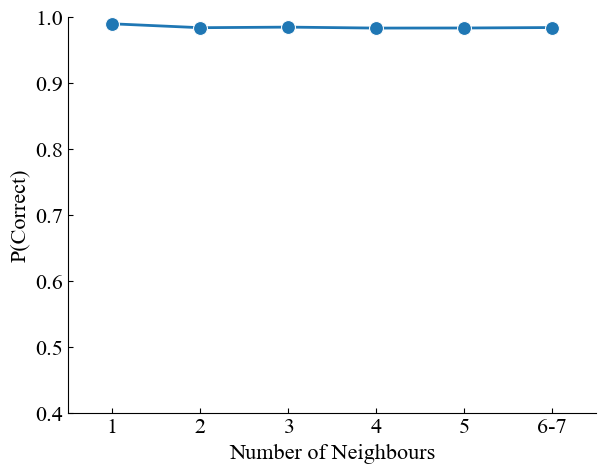

In [196]:
# Plot neighbourhood effect
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(
    data=df_neighbour_group,
    x="neighbour_group",
    y="correct",
    linewidth=2,
    marker="o",
    markersize=10,
    label=str(thresh),
)
plt.ylim([0.4, 1])
plt.xlim([0.5, 6.5])
plt.xticks(ticks=np.arange(1, 7), labels=["1", "2", "3", "4", "5", "6-7"])
plt.xlabel("Number of Neighbours")
plt.ylabel("P(Correct)")
plt.legend().set_visible(False)

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu8_g1_correct-neighbor.pdf")
plt.show()

### ILI

In [197]:
# Detect ILI responses
def get_ILI(df_tmp):
    resp_names = df_tmp["s_resp"].values
    study_names = df_tmp["correct_ans"].values  # all correct answers are all studied names
    is_studied = np.isin(resp_names, study_names)
    is_incorrect = df_tmp["correct"] == False
    is_ILI = is_studied & is_incorrect
    return is_ILI


df_simu_g1["ILI"] = df_simu_g1.groupby("session").apply(get_ILI).to_frame(name="ILI").reset_index()["ILI"].to_list()
df_ILI = df_simu_g1.query("ILI == True").copy()
df_ILI

/var/folders/js/fb9kwys10ln8jgq1bxxqg0tr0000gn/T/ipykernel_15539/3045370957.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_simu_g1["ILI"] = df_simu_g1.groupby("session").apply(get_ILI).to_frame(name="ILI").reset_index()["ILI"].to_list()


,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test,group,correct,neighbour,neighbour_group,ILI
13,1,0,9,31,1930,0.333082,Face9,22,6,1,1,False,2,2,True
424,53,0,16,27,1130,0.324711,Face16,20,6,1,1,False,3,3,True
450,56,0,10,24,920,0.329197,Face10,26,6,1,1,False,5,5,True
465,58,0,4,19,1260,0.333371,Face4,25,6,1,1,False,3,3,True
483,60,0,1,25,880,0.186648,Face1,26,5,1,1,False,4,4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79709,9963,0,4,30,950,0.330536,Face4,20,4,1,1,False,4,4,True
79770,9971,0,4,17,1330,0.216496,Face4,26,6,1,1,False,5,5,True
79784,9973,0,10,28,1230,0.330139,Face10,27,6,1,1,False,5,5,True
79932,9991,0,13,17,1450,0.335499,Face13,20,7,1,1,False,5,5,True


In [198]:
# Get name-face pair dict for each session
sess_name_face = {}
for sess in df_study_g1.session.unique():
    sess_name_face[sess] = df_study_g1.query(f"session == {sess}")[["study_itemno1", "study_itemno2"]].set_index("study_itemno2").to_dict()["study_itemno1"]

In [199]:
# Get distance between ILI and correct faces
df_ILI["resp_face"] = df_ILI.apply(lambda x: sess_name_face[x["session"]][x["s_resp"]], axis=1)
df_ILI["resp_corr_distance"] = df_ILI.apply(lambda x: face_distance[x["test_itemno"] - 1, x["resp_face"] - 1], axis=1)
df_ILI["distance_bin"] = df_ILI.apply(lambda x: str(0.5 * (x["resp_corr_distance"] // 0.5 + 1)) if x["resp_corr_distance"] < 3.5 else ">3.5", axis=1)
df_ILI["distance_bin"] = pd.Categorical(df_ILI["distance_bin"], categories=["1.0", "1.5", "2.0", "2.5", "3.0", "3.5", ">3.5"], ordered=True)
df_ILI

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test,group,correct,neighbour,neighbour_group,ILI,resp_face,resp_corr_distance,distance_bin
13,1,0,9,31,1930,0.333082,Face9,22,6,1,1,False,2,2,True,5,3.3562,3.5
424,53,0,16,27,1130,0.324711,Face16,20,6,1,1,False,3,3,True,11,3.6030,>3.5
450,56,0,10,24,920,0.329197,Face10,26,6,1,1,False,5,5,True,8,3.3644,3.5
465,58,0,4,19,1260,0.333371,Face4,25,6,1,1,False,3,3,True,16,2.6255,3.0
483,60,0,1,25,880,0.186648,Face1,26,5,1,1,False,4,4,True,3,1.0900,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79709,9963,0,4,30,950,0.330536,Face4,20,4,1,1,False,4,4,True,16,2.6255,3.0
79770,9971,0,4,17,1330,0.216496,Face4,26,6,1,1,False,5,5,True,6,1.6479,2.0
79784,9973,0,10,28,1230,0.330139,Face10,27,6,1,1,False,5,5,True,2,2.7967,3.0
79932,9991,0,13,17,1450,0.335499,Face13,20,7,1,1,False,5,5,True,5,2.4045,2.5


In [200]:
# Count possible ILI from all distances
distance_cnt = {}
for lst in distance_lsts:
    for d in lst:
        d_group = str(0.5 * (d // 0.5 + 1)) if d < 3.5 else ">3.5"
        if d_group in distance_cnt:
            distance_cnt[d_group] += 1
        else:
            distance_cnt[d_group] = 1

In [201]:
# Get ILI probability by distance bin
df_ILI_distance = df_ILI.groupby("distance_bin")["test_itemno"].count().to_frame(name="ILI_cnt").reset_index()
df_ILI_distance["ILI_poss"] = df_ILI_distance.apply(lambda x: distance_cnt[x["distance_bin"]], axis=1)
df_ILI_distance["ILI_prob"] = df_ILI_distance["ILI_cnt"] / df_ILI_distance["ILI_poss"]
df_ILI_distance

/var/folders/js/fb9kwys10ln8jgq1bxxqg0tr0000gn/T/ipykernel_15539/2353333076.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_ILI_distance = df_ILI.groupby("distance_bin")["test_itemno"].count().to_frame(name="ILI_cnt").reset_index()


,distance_bin,ILI_cnt,ILI_poss,ILI_prob
0,1.0,47,9136,0.005144
1,1.5,102,28218,0.003615
2,2.0,69,27948,0.002469
3,2.5,186,102562,0.001814
4,3.0,219,131028,0.001671
5,3.5,254,163462,0.001554
6,>3.5,126,97646,0.001290


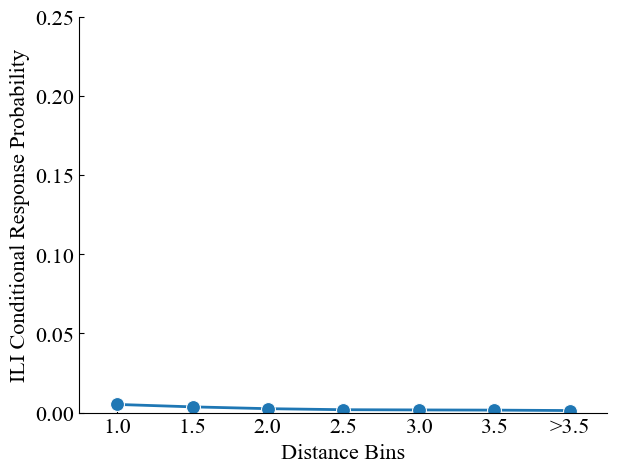

In [202]:
# Plot ILI by distance bin
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_ILI_distance, x="distance_bin", y="ILI_prob", linewidth=2, marker="o", markersize=10)
plt.ylim([0, 0.25])
plt.xlim([-0.5, 6.5])
plt.xlabel("Distance Bins")
plt.ylabel("ILI Conditional Response Probability")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu8_g1_ILI-distance.pdf")
plt.show()

## Err Check

In [203]:
# Load ground truth
with open("data/simu8_gt.json") as f:
    gt = json.load(f)
neighbor_mean_gt = np.array(gt["exp1_neighbor_mean"])
neighbor_se_gt = np.array(gt["exp1_neighbor_se"])
ILI_mean_gt = np.array(gt["exp1_ILI_mean"])
ILI_se_gt = np.array(gt["exp1_ILI_se"])

In [204]:
# Compute weighted mean squared error
neighbor_mean = df_neighbour_group["correct"].to_numpy()
ILI_mean = df_ILI_distance["ILI_prob"].to_numpy()
wls_neighbor = get_wmse(neighbor_mean_gt, neighbor_mean, neighbor_se_gt) / len(neighbor_mean_gt)
wls_ILI = get_wmse(ILI_mean_gt, ILI_mean, ILI_se_gt) / len(ILI_mean_gt)
wls_neighbor, wls_ILI

(57.615898666138754, 46.45950024865339)

In [205]:
# Compute total error
err = wls_neighbor + wls_ILI
err

104.07539891479215

# Group 2

In [173]:
df_study_g2 = df_study.query("group == 2").copy()
df_test_g2 = df_test.query("group == 2").copy()

## Run CMR-IA

In [174]:
# Define parameters and load PSO results
params_path = "/Users/bei/BeiWorld/Research/2022CMRIA/CMR_IA/Analysis/simuS1_recog_cr/data/simuS1_params.json"
params = cmr.load_params("S1", params_path=params_path, fixed_params={"learn_while_retrieving": True, "nitems_in_accumulator": 32, "ban_recall": np.arange(1, 17)})
params

{'beta_enc': 0.613711,
 'beta_rec': 0.611305,
 'beta_cue': 0.986796,
 'beta_rec_post': 0.999995,
 'beta_distract': 0.408592,
 'beta_enc_inpair': None,
 's_fc': 0.060385,
 's_cf': 0.217875,
 'phi_s': 2.424486,
 'phi_d': 3.04304,
 'psi_s': 0.0,
 'psi_c': 1.0,
 'd_assoc': None,
 'use_new_context': True,
 'use_flexible_thresh': True,
 'c_d': 2.817642,
 'thresh_kernel_len': 10,
 'c_thresh_itm': 1.165438,
 'c_thresh_assoc': 1.024938,
 'c_s': 0.0,
 'thresh_sigma': 0.0,
 'recog_slope': 1.0,
 'kappa': 0.428492,
 'eta': 0.147015,
 'omega': 8.622752,
 'alpha': 0.533889,
 'lamb': 0.023294,
 'c_thresh': 0.18099,
 'ban_recall': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 32,
 'max_recalls': 50,
 'learn_while_retrieving': True,
 'gamma_fc': 0.445102,
 'gamma_cf': 0.701424}

In [175]:
# Run model or load saved results
if SAVERES2:
    df_simu_g2, f_in, f_dif = cmr.run_success_multi_sess(params, df_study_g2, df_test_g2, sem_mat, mode="Recog-CR", design="S1G3")
    df_simu_g2["test"] = df_test_g2["test"]
    df_simu_g2 = df_simu_g2.merge(df_test_g2, on=["session", "list", "test", "test_itemno1", "test_itemno2"])
#     df_simu_g2.to_parquet("data/simu8_result_g2.parquet")
# else:
#     df_simu_g2 = pd.read_parquet("data/simu8_result_g2.parquet")
df_simu_g2

100%|██████████| 10000/10000 [00:59<00:00, 169.21it/s]


CMR Time: 59.507174253463745


,session,list,test_itemno1,test_itemno2,s_resp,s_rt,csim,thresh,test,test_item1,test_item2,correct_ans,study_pos,group
0,0,0,15,30,1,0,0.585504,0.346634,1,Face15,Mike,1,-1,2
1,0,0,4,17,0,0,0.578032,0.584961,1,Face4,Jim,1,-1,2
2,0,0,10,28,0,0,0.146246,0.592000,1,Face10,Paul,0,-1,2
3,0,0,2,23,1,0,0.569686,0.176307,1,Face2,Charles,1,-1,2
4,0,0,1,27,0,0,0.086245,0.559541,1,Face1,Dan,0,-1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319995,9999,0,12,-1,18,1170,0.604302,0.180990,2,Face12,None,18,11,2
319996,9999,0,3,-1,25,580,0.802213,0.180990,2,Face3,None,25,15,2
319997,9999,0,10,-1,-2,-2,0.163259,0.180990,2,Face10,None,26,13,2
319998,9999,0,16,-1,19,1680,0.481097,0.180990,2,Face16,None,19,0,2


## Analysis

In [176]:
# Split recognition and cued recall responses
df_recog = df_simu_g2.query("test == 1").copy()
df_cr = df_simu_g2.query("test == 2").copy()

In [177]:
# Get name-face pair dict for each session
sess_name_face = {}
for sess in df_study_g2.session.unique():
    sess_name_face[sess] = df_study_g2.query(f"session == {sess}")[["study_itemno1", "study_itemno2"]].set_index("study_itemno2").to_dict()["study_itemno1"]

### Neighborhood Effect

In [178]:
# Load face distance matrix and compute neighbour counts (all 16 faces studied every session)
face_distance = np.load("data/simu8_distance.npy")
thresh = 3.0
neighbour_count = ((face_distance < thresh) & (face_distance > 0)).sum(axis=1)

# Density group of each recognition probe face
df_recog["neighbour"] = df_recog["test_itemno1"].apply(lambda f: neighbour_count[f - 1])
df_recog["density"] = pd.cut(df_recog["neighbour"], [4, 6, 8, 10], labels=["low", "medium", "high"])
df_recog["yes"] = (df_recog["s_resp"] == 1).astype(int)
df_recog

,session,list,test_itemno1,test_itemno2,s_resp,s_rt,csim,thresh,test,test_item1,test_item2,correct_ans,study_pos,group,neighbour,density,yes
0,0,0,15,30,1,0,0.585504,0.346634,1,Face15,Mike,1,-1,2,10,high,1
1,0,0,4,17,0,0,0.578032,0.584961,1,Face4,Jim,1,-1,2,6,low,0
2,0,0,10,28,0,0,0.146246,0.592000,1,Face10,Paul,0,-1,2,10,high,0
3,0,0,2,23,1,0,0.569686,0.176307,1,Face2,Charles,1,-1,2,8,medium,1
4,0,0,1,27,0,0,0.086245,0.559541,1,Face1,Dan,0,-1,2,10,high,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319979,9999,0,13,20,0,0,0.585482,0.589455,1,Face13,Bill,1,-1,2,8,medium,0
319980,9999,0,6,28,0,0,0.568118,0.599448,1,Face6,Paul,1,-1,2,7,medium,0
319981,9999,0,12,17,0,0,0.358004,0.583311,1,Face12,Jim,0,-1,2,8,medium,0
319982,9999,0,8,21,1,0,0.580598,0.379860,1,Face8,Dave,1,-1,2,5,low,1


In [179]:
# Hit rate and false alarm rate by density
df_hr = df_recog.query("correct_ans == 1").groupby("density", observed=True).yes.mean().reset_index(name="HR")
df_far = df_recog.query("correct_ans == 0").groupby("density", observed=True).yes.mean().reset_index(name="FAR")
df_hr, df_far

(  density        HR
 0     low  0.742229
 1  medium  0.734828
 2    high  0.734863,
   density       FAR
 0     low  0.232165
 1  medium  0.226380
 2    high  0.223091)

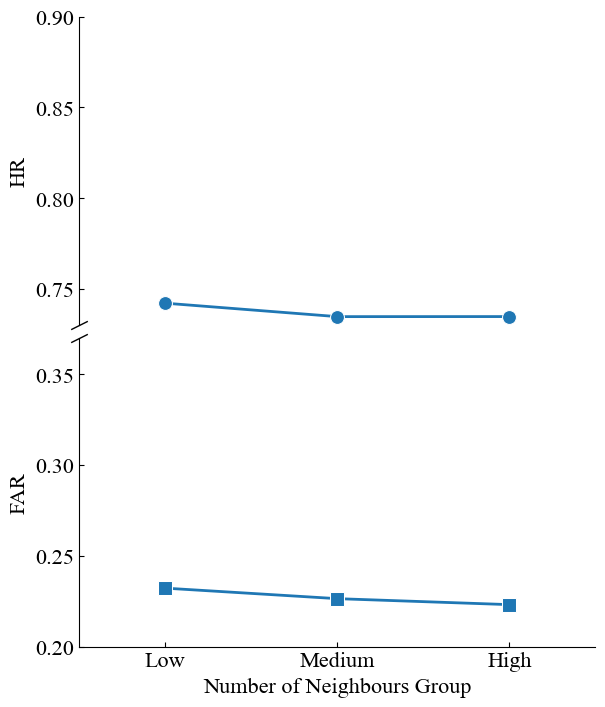

In [ ]:
# Plot hit rate and false alarm rate by density (stacked, broken y-axis)
xpos = np.arange(3)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 7))
fig.subplots_adjust(left=0.12, right=0.98, bottom=0.08, top=0.98, hspace=0.04)

sns.lineplot(x=xpos, y=df_hr["HR"].to_numpy(), ax=ax1, marker="o", color="C0", markersize=10, linewidth=2)
sns.lineplot(x=xpos, y=df_far["FAR"].to_numpy(), ax=ax2, marker="s", color="C0", markersize=10, linewidth=2)

ax1.set_ylim(0.73, 0.90)
ax2.set_ylim(0.20, 0.37)
for ax in (ax1, ax2):
    ax.tick_params(axis="y", direction="in")
    ax.tick_params(axis="x", direction="in")
    ax.spines.right.set_visible(False)
ax1.spines.bottom.set_visible(False)
ax1.spines.top.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.tick_params(axis="x", which="both", bottom=False)

# Slanted break marks between the two panels
d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", color="k", mec="k", mew=1, clip_on=False)
ax1.plot(0, 0, transform=ax1.transAxes, **kwargs)
ax2.plot(0, 1, transform=ax2.transAxes, **kwargs)

ax2.set_xticks(xpos)
ax2.set_xticklabels(["Low", "Medium", "High"])
ax2.set_xlim(-0.5, 2.5)
ax1.set_ylabel("HR")
ax2.set_ylabel("FAR")
ax2.set_xlabel("Number of Neighbours Group")

if SAVEFIG:
    ax1.set_ylabel(None)
    ax2.set_ylabel(None)
    ax2.set_xlabel(None)
    plt.savefig("figures/simu8_g2_hrfar-neighbor.pdf")
plt.show()

### Probe Distance Effect

In [ ]:
# Distance from each lure probe to the studied face of its (mismatched) name; targets sit at distance 0
def get_probe_distance(x):
    if x["correct_ans"] == 1:
        return 0.0
    resp_face = sess_name_face[x["session"]][x["test_itemno2"]]
    return face_distance[x["test_itemno1"] - 1, resp_face - 1]


lure_edges = [0.5, 1.5, 2.5, 3.5, 4.5]
lure_labels = ["1.5", "2.5", "3.5", "4.5"]
df_recog["probe_distance"] = df_recog.apply(get_probe_distance, axis=1)
df_recog["distance_bin"] = np.where(df_recog["correct_ans"] == 1, "Targets", pd.cut(df_recog["probe_distance"], lure_edges, labels=lure_labels).astype(object))
dbin_order = ["Targets"] + lure_labels
df_recog

,session,list,test_itemno1,test_itemno2,s_resp,s_rt,csim,thresh,test,test_item1,test_item2,correct_ans,study_pos,group,neighbour,density,yes,probe_distance,distance_bin
0,0,0,15,30,1,0,0.585504,0.346634,1,Face15,Mike,1,-1,2,10,high,1,0.0000,Targets
1,0,0,4,17,0,0,0.578032,0.584961,1,Face4,Jim,1,-1,2,6,low,0,0.0000,Targets
2,0,0,10,28,0,0,0.146246,0.592000,1,Face10,Paul,0,-1,2,10,high,0,2.2956,2.5
3,0,0,2,23,1,0,0.569686,0.176307,1,Face2,Charles,1,-1,2,8,medium,1,0.0000,Targets
4,0,0,1,27,0,0,0.086245,0.559541,1,Face1,Dan,0,-1,2,10,high,0,2.7583,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319979,9999,0,13,20,0,0,0.585482,0.589455,1,Face13,Bill,1,-1,2,8,medium,0,0.0000,Targets
319980,9999,0,6,28,0,0,0.568118,0.599448,1,Face6,Paul,1,-1,2,7,medium,0,0.0000,Targets
319981,9999,0,12,17,0,0,0.358004,0.583311,1,Face12,Jim,0,-1,2,8,medium,0,2.4857,2.5
319982,9999,0,8,21,1,0,0.580598,0.379860,1,Face8,Dave,1,-1,2,5,low,1,0.0000,Targets


In [ ]:
# Yes rate by probe distance bin
df_yes_distance = df_recog.groupby("distance_bin").yes.mean().reindex(dbin_order).reset_index(name="yes_rate")
df_yes_distance

,distance_bin,yes_rate
0,Targets,0.736225
1,1.5,0.165390
2,2.5,0.166939
3,3.5,0.162113
4,4.5,0.153921


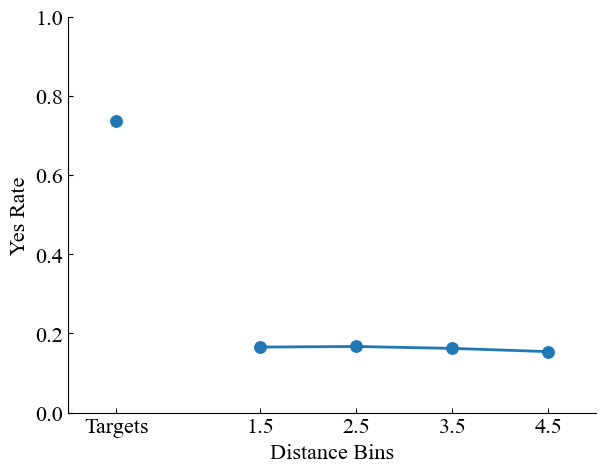

In [ ]:
# Plot yes rate by probe distance
xpos = [0, 1.5, 2.5, 3.5, 4.5]
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_yes_distance, x=xpos, y="yes_rate", ax=ax, marker="o", color="C0", markersize=10, linewidth=0)
sns.lineplot(data=df_yes_distance.query("distance_bin != 'Targets'"), x=xpos[1:], y="yes_rate", ax=ax, marker=None, color="C0", markersize=10, linewidth=2, linestyle="-")
plt.xlim([-0.5, 5])
plt.ylim([0, 1])
plt.xticks(ticks=xpos, labels=df_yes_distance["distance_bin"])
plt.xlabel("Distance Bins")
plt.ylabel("Yes Rate")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu8_g2_yes-distance.pdf")
plt.show()

### Final Cued Recall

In [ ]:
# Correct flag and recalled-name distance for in-space responses (drop omissions and no-responses)
fin_edges = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
fin_labels = ["0", "1.5", "2.5", "3.5", "4.5"]
df_cr["correct"] = df_cr["s_resp"] == df_cr["correct_ans"]
df_recalled = df_cr.query("s_resp > 0").copy()
df_recalled["resp_face"] = df_recalled.apply(lambda x: x["test_itemno1"] if x["correct"] else sess_name_face[x["session"]][x["s_resp"]], axis=1)
df_recalled["resp_distance"] = df_recalled.apply(lambda x: face_distance[x["test_itemno1"] - 1, x["resp_face"] - 1], axis=1)
df_recalled["distance_bin"] = pd.cut(df_recalled["resp_distance"], fin_edges, labels=fin_labels)
df_recalled

,session,list,test_itemno1,test_itemno2,s_resp,s_rt,csim,thresh,test,test_item1,test_item2,correct_ans,study_pos,group,correct,resp_face,resp_distance,distance_bin
16,0,0,16,-1,23,1290,0.279267,0.18099,2,Face16,None,25,6,2,False,2,3.1521,3.5
17,0,0,1,-1,24,1070,0.484310,0.18099,2,Face1,None,24,0,2,True,1,0.0000,0
18,0,0,13,-1,19,1250,0.516457,0.18099,2,Face13,None,19,2,2,True,13,0.0000,0
19,0,0,10,-1,18,1090,0.357570,0.18099,2,Face10,None,21,8,2,False,5,3.5080,4.5
20,0,0,14,-1,30,1390,0.296878,0.18099,2,Face14,None,28,14,2,False,15,2.1647,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319994,9999,0,14,-1,17,940,0.349527,0.18099,2,Face14,None,32,9,2,False,2,3.4535,3.5
319995,9999,0,12,-1,18,1170,0.604302,0.18099,2,Face12,None,18,11,2,True,12,0.0000,0
319996,9999,0,3,-1,25,580,0.802213,0.18099,2,Face3,None,25,15,2,True,3,0.0000,0
319998,9999,0,16,-1,19,1680,0.481097,0.18099,2,Face16,None,19,0,2,True,16,0.0000,0


In [ ]:
# Count possible responses: distance from each cued face to all 16 faces (self = 0 = correct option)
recall_poss = pd.cut(face_distance[df_cr["test_itemno1"].to_numpy() - 1, :].ravel(), fin_edges, labels=fin_labels).value_counts()

# Conditional recall probability by distance bin
df_recall_distance = df_recalled.groupby("distance_bin", observed=False).size().to_frame(name="recall_cnt").reset_index()
df_recall_distance["recall_poss"] = df_recall_distance["distance_bin"].map(recall_poss)
df_recall_distance["recall_prob"] = df_recall_distance["recall_cnt"] / df_recall_distance["recall_poss"]
df_recall_distance

,distance_bin,recall_cnt,recall_poss,recall_prob
0,0,74877,160000,0.467981
1,1.5,5120,160000,0.032000
2,2.5,17247,560000,0.030798
3,3.5,36164,1260000,0.028702
4,4.5,11451,420000,0.027264


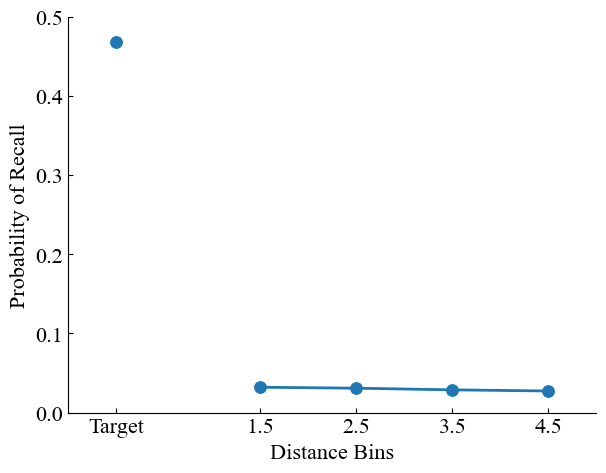

In [ ]:
# Plot final cued recall probability by distance
xpos = [0, 1.5, 2.5, 3.5, 4.5]
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_recall_distance, x=xpos, y="recall_prob", ax=ax, marker="o", color="C0", markersize=10, linewidth=0)
sns.lineplot(data=df_recall_distance.query("distance_bin != '0'"), x=xpos[1:], y="recall_prob", ax=ax, marker=None, color="C0", markersize=10, linewidth=2, linestyle="-")
plt.xlim([-0.5, 5])
plt.ylim([0, 0.5])
plt.xticks(ticks=xpos, labels=["Target", "1.5", "2.5", "3.5", "4.5"])
plt.xlabel("Distance Bins")
plt.ylabel("Probability of Recall")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu8_g2_cr-distance.pdf")
plt.show()

## Err Check

In [ ]:
# Load ground truth
with open("data/simu8_gt.json") as f:
    gt = json.load(f)
hr_mean_gt = np.array(gt["exp3_neighbor_hr_mean"])
hr_se_gt = np.array(gt["exp3_neighbor_hr_se"])
far_mean_gt = np.array(gt["exp3_neighbor_far_mean"])
far_se_gt = np.array(gt["exp3_neighbor_far_se"])
yesdist_mean_gt = np.array(gt["exp3_yesdist_mean"])
yesdist_se_gt = np.array(gt["exp3_yesdist_se"])
crdist_mean_gt = np.array(gt["exp3_crdist_mean"])
crdist_se_gt = np.array(gt["exp3_crdist_se"])

In [ ]:
# Compute weighted mean squared error
hr_mean = df_hr["HR"].to_numpy()
far_mean = df_far["FAR"].to_numpy()
yesdist_mean = df_yes_distance["yes_rate"].to_numpy()
crdist_mean = df_recall_distance["recall_prob"].to_numpy()
wls_hr = get_wmse(hr_mean_gt, hr_mean, hr_se_gt) / len(hr_mean_gt)
wls_far = get_wmse(far_mean_gt, far_mean, far_se_gt) / len(far_mean_gt)
wls_yesdist = get_wmse(yesdist_mean_gt, yesdist_mean, yesdist_se_gt) / len(yesdist_mean_gt)
wls_crdist = get_wmse(crdist_mean_gt, crdist_mean, crdist_se_gt) / len(crdist_mean_gt)
wls_hr, wls_far, wls_yesdist, wls_crdist

(11.571511513228415, 10.407181480885752, 36.07627392764819, 22.085166994388423)

In [ ]:
# Compute total error
err = wls_hr + wls_far + wls_yesdist + wls_crdist
err

80.14013391615077

In [ ]:
# g1 + g2 error
err = wls_neighbor + wls_ILI + wls_hr + wls_far + wls_yesdist + wls_crdist
err

84.76662682900397